## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    multilabel_confusion_matrix
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 2. Carga y Preprocesamiento del Dataset

In [2]:
# Cargar el dataset con synonym augmentation
import os

df = pd.read_csv('../resources/dataset/synonym_youtoxic_english_1000.csv', index_col=0)
print("✓ Usando dataset con SYNONYM AUGMENTATION")

# Definir las etiquetas a usar
labels = ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']

print(f"\nForma del dataset: {df.shape}")
print(f"Etiquetas a analizar: {labels}")
print("\nPrimeras filas:")
df.head()

✓ Usando dataset con SYNONYM AUGMENTATION

Forma del dataset: (3751, 15)
Etiquetas a analizar: ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']

Primeras filas:


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement embody not train to shoot to a...,True,True,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement make up not trained to shoot t...,True,True,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Legal philosophy enforcement is not trained to...,True,True,False,False,False,False,False,False,False,False,False,False


In [3]:
def clean_text(text):
    """Limpia el texto para el procesamiento"""
    if pd.isna(text):
        return ""
    
    # Convertir a minúsculas
    text = text.lower()
    
    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Eliminar menciones y hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Eliminar caracteres especiales y números (mantener letras y espacios)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Aplicar limpieza
print("Limpiando texto...")
df['cleaned_text'] = df['Text'].apply(clean_text)

# Eliminar filas con texto vacío
df = df[df['cleaned_text'].str.len() > 0]

print(f"Filas después de limpieza: {len(df)}")

Limpiando texto...
Filas después de limpieza: 3749


## 3. División del Dataset (Train-Test 80-20)

In [4]:
# Preparar X e y
X = df['cleaned_text']
y = df[labels].astype(int)

print("="*80)
print("ESTRATEGIA: TRAIN-TEST SPLIT SIMPLE (80-20)")
print("="*80)
print("""
1. División simple: 80% Train y 20% Test
2. El modelo se entrena con el 80% de los datos
3. Evaluación final con el 20% Test
""")

# Split simple 80-20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y['IsToxic']
)

print(f"\n{'='*80}")
print("DISTRIBUCIÓN DE DATOS:")
print(f"{'='*80}")
print(f"Dataset completo:          {len(X):>6} muestras (100.0%)")
print(f"Conjunto de Train:         {len(X_train):>6} muestras ({len(X_train)/len(X)*100:>5.1f}%)")
print(f"Conjunto de Test:          {len(X_test):>6} muestras ({len(X_test)/len(X)*100:>5.1f}%)")

print(f"\n{'='*80}")
print("DISTRIBUCIÓN DE ETIQUETAS:")
print(f"{'='*80}")
print(f"\n{'Etiqueta':<15} {'Train':>10} {'Test':>10}")
print("-" * 80)
for label in labels:
    print(f"{label:<15} {y_train[label].sum():>10} {y_test[label].sum():>10}")
print("="*80)

ESTRATEGIA: TRAIN-TEST SPLIT SIMPLE (80-20)

1. División simple: 80% Train y 20% Test
2. El modelo se entrena con el 80% de los datos
3. Evaluación final con el 20% Test


DISTRIBUCIÓN DE DATOS:
Dataset completo:            3749 muestras (100.0%)
Conjunto de Train:           2999 muestras ( 80.0%)
Conjunto de Test:             750 muestras ( 20.0%)

DISTRIBUCIÓN DE ETIQUETAS:

Etiqueta             Train       Test
--------------------------------------------------------------------------------
IsToxic               2569        643
IsAbusive             1974        476
IsProvocative          881        225
IsObscene              561        139
IsHatespeech           757        208
IsRacist               679        195


## 4. Vectorización con TF-IDF

In [5]:
# Vectorización TF-IDF con parámetros para evitar overfitting
tfidf = TfidfVectorizer(
    max_features=5000,  # Limitar características para evitar overfitting
    min_df=2,           # Ignorar términos muy raros
    max_df=0.8,         # Ignorar términos muy comunes
    ngram_range=(1, 2), # Unigramas y bigramas
    strip_accents='unicode',
    lowercase=True,
    stop_words='english'
)

print("Vectorizando texto con TF-IDF...")
print("\nIMPORTANTE: El vectorizador se entrena SOLO con datos de Train")
print("Test se transforma usando el vectorizador ya entrenado\n")

# Entrenar vectorizador SOLO con datos de Train
X_train_tfidf = tfidf.fit_transform(X_train)

# Transformar Test (sin re-entrenar el vectorizador)
X_test_tfidf = tfidf.transform(X_test)

print(f"Forma de X_train_tfidf:      {X_train_tfidf.shape}")
print(f"Forma de X_test_tfidf:       {X_test_tfidf.shape}")
print(f"\nNúmero de características: {len(tfidf.get_feature_names_out())}")

Vectorizando texto con TF-IDF...

IMPORTANTE: El vectorizador se entrena SOLO con datos de Train
Test se transforma usando el vectorizador ya entrenado

Forma de X_train_tfidf:      (2999, 5000)
Forma de X_test_tfidf:       (750, 5000)

Número de características: 5000


## 5. Entrenamiento del Modelo SVM Multi-Etiqueta

In [6]:
# Entrenar modelo SVM multi-etiqueta con regularización
print("="*80)
print("ENTRENANDO MODELO SVM MULTI-ETIQUETA")
print("="*80)
print("\nIMPORTANTE: El modelo se entrena SOLO con datos de Train")
print("Test se reserva para la evaluación final\n")

# C más bajo = más regularización = menos overfitting
# class_weight='balanced' ajusta automáticamente los pesos para clases desbalanceadas
base_svm = LinearSVC(C=0.1, class_weight='balanced', random_state=42, max_iter=2000, dual=False)
svm_multilabel = OneVsRestClassifier(base_svm)

# Entrenar SOLO con Train
svm_multilabel.fit(X_train_tfidf, y_train)

# Predicciones en Train y Test
y_train_pred = svm_multilabel.predict(X_train_tfidf)
y_test_pred = svm_multilabel.predict(X_test_tfidf)

print("✓ Modelo entrenado exitosamente")
print(f"✓ Predicciones generadas para Train y Test")

ENTRENANDO MODELO SVM MULTI-ETIQUETA

IMPORTANTE: El modelo se entrena SOLO con datos de Train
Test se reserva para la evaluación final

✓ Modelo entrenado exitosamente
✓ Predicciones generadas para Train y Test


## 6. Evaluación Detallada del Modelo

In [7]:
# Función para evaluar con Train-Test simple
def evaluate_multilabel_model(y_train_true, y_train_pred, y_test_true, y_test_pred, label_names):
    """Evalúa el modelo multi-etiqueta con Train-Test split"""
    
    results = []
    
    print(f"\n{'='*100}")
    print(f"EVALUACIÓN DEL MODELO MULTI-ETIQUETA (Train-Test 80-20)")
    print(f"{'='*100}")
    
    print(f"\n{'Etiqueta':<15} {'Train F1':>10} {'Test F1':>10} {'Overfitting':>15} {'Estado':>15}")
    print("-" * 100)
    
    for i, label in enumerate(label_names):
        # Métricas de Train
        train_acc = accuracy_score(y_train_true.iloc[:, i], y_train_pred[:, i])
        train_f1 = f1_score(y_train_true.iloc[:, i], y_train_pred[:, i], zero_division=0)
        train_prec = precision_score(y_train_true.iloc[:, i], y_train_pred[:, i], zero_division=0)
        train_rec = recall_score(y_train_true.iloc[:, i], y_train_pred[:, i], zero_division=0)
        
        # Métricas de Test
        test_acc = accuracy_score(y_test_true.iloc[:, i], y_test_pred[:, i])
        test_f1 = f1_score(y_test_true.iloc[:, i], y_test_pred[:, i], zero_division=0)
        test_prec = precision_score(y_test_true.iloc[:, i], y_test_pred[:, i], zero_division=0)
        test_rec = recall_score(y_test_true.iloc[:, i], y_test_pred[:, i], zero_division=0)
        
        # Diferencia (overfitting)
        diff_train_test = (train_f1 - test_f1) * 100
        
        # Estado de overfitting
        if abs(diff_train_test) < 5:
            status = "✓ OK"
            color = "🟢"
        elif abs(diff_train_test) < 10:
            status = "⚠ Leve"
            color = "🟡"
        else:
            status = "❌ Alto"
            color = "🔴"
        
        print(f"{label:<15} {train_f1:>10.4f} {test_f1:>10.4f} {diff_train_test:>14.2f}% {color} {status:>12}")
        
        results.append({
            'label': label,
            'train_acc': train_acc,
            'test_acc': test_acc,
            'train_f1': train_f1,
            'test_f1': test_f1,
            'train_prec': train_prec,
            'test_prec': test_prec,
            'train_rec': train_rec,
            'test_rec': test_rec,
            'overfitting_%': diff_train_test
        })
    
    print("-" * 100)
    
    # Promedios
    avg_train_f1 = np.mean([r['train_f1'] for r in results])
    avg_test_f1 = np.mean([r['test_f1'] for r in results])
    avg_overfitting = (avg_train_f1 - avg_test_f1) * 100
    
    print(f"{'PROMEDIO':<15} {avg_train_f1:>10.4f} {avg_test_f1:>10.4f} {avg_overfitting:>14.2f}%")
    
    # Métricas globales
    hamming_train = hamming_loss(y_train_true, y_train_pred)
    hamming_test = hamming_loss(y_test_true, y_test_pred)
    
    print(f"\n{'='*100}")
    print(f"MÉTRICAS GLOBALES:")
    print(f"{'='*100}")
    print(f"Hamming Loss Train:      {hamming_train:.4f}")
    print(f"Hamming Loss Test:       {hamming_test:.4f}")
    
    # Verificar overfitting
    max_overfitting = max([abs(r['overfitting_%']) for r in results])
    
    print(f"\n{'='*100}")
    print(f"ANÁLISIS DE OVERFITTING (Train vs Test):")
    print(f"{'='*100}")
    print(f"Diferencia máxima en F1-Score: {max_overfitting:.2f}%")
    print(f"Diferencia promedio en F1-Score: {avg_overfitting:.2f}%")
    
    if max_overfitting < 5:
        print(f"✅ NO HAY OVERFITTING (diferencia < 5%)")
    elif max_overfitting < 10:
        print(f"⚠️  OVERFITTING LEVE (diferencia 5-10%)")
    else:
        print(f"❌ OVERFITTING SIGNIFICATIVO (diferencia > 10%)")
    
    print(f"\n{'='*100}")
    print(f"RENDIMIENTO FINAL (Test Set):")
    print(f"{'='*100}")
    print(f"F1-Score Promedio en Test: {avg_test_f1:.4f}")
    print(f"Este es el rendimiento real esperado en producción")
    print(f"{'='*100}\n")
    
    return pd.DataFrame(results)

# Evaluar modelo
results_df = evaluate_multilabel_model(y_train, y_train_pred, y_test, y_test_pred, labels)


EVALUACIÓN DEL MODELO MULTI-ETIQUETA (Train-Test 80-20)

Etiqueta          Train F1    Test F1     Overfitting          Estado
----------------------------------------------------------------------------------------------------
IsToxic             0.9805     0.9385           4.20% 🟢         ✓ OK
IsAbusive           0.9732     0.9256           4.76% 🟢         ✓ OK
IsProvocative       0.9484     0.8419          10.65% 🔴       ❌ Alto
IsObscene           0.9661     0.8975           6.86% 🟡       ⚠ Leve
IsHatespeech        0.9436     0.8981           4.54% 🟢         ✓ OK
IsRacist            0.9392     0.8916           4.76% 🟢         ✓ OK
----------------------------------------------------------------------------------------------------
PROMEDIO            0.9585     0.8989           5.96%

MÉTRICAS GLOBALES:
Hamming Loss Train:      0.0285
Hamming Loss Test:       0.0751

ANÁLISIS DE OVERFITTING (Train vs Test):
Diferencia máxima en F1-Score: 10.65%
Diferencia promedio en F1-Score: 5.96%

## 7. Reportes de Clasificación Detallados

In [8]:
print("\n" + "="*120)
print("📋 REPORTES DE CLASIFICACIÓN DETALLADOS POR ETIQUETA")
print("="*120)

# Reporte detallado para cada etiqueta
for i, label in enumerate(labels):
    print(f"\n{'='*120}")
    print(f"🏷️  {label}")
    print(f"{'='*120}")
    
    print(f"\n📊 TRAIN SET:")
    print(classification_report(
        y_train.iloc[:, i], 
        y_train_pred[:, i],
        target_names=['Negativo', 'Positivo'],
        digits=4,
        zero_division=0
    ))
    
    print(f"\n📊 TEST SET:")
    print(classification_report(
        y_test.iloc[:, i], 
        y_test_pred[:, i],
        target_names=['Negativo', 'Positivo'],
        digits=4,
        zero_division=0
    ))


📋 REPORTES DE CLASIFICACIÓN DETALLADOS POR ETIQUETA

🏷️  IsToxic

📊 TRAIN SET:
              precision    recall  f1-score   support

    Negativo     0.8371    0.9558    0.8925       430
    Positivo     0.9924    0.9689    0.9805      2569

    accuracy                         0.9670      2999
   macro avg     0.9147    0.9623    0.9365      2999
weighted avg     0.9701    0.9670    0.9679      2999


📊 TEST SET:
              precision    recall  f1-score   support

    Negativo     0.6160    0.7196    0.6638       107
    Positivo     0.9520    0.9253    0.9385       643

    accuracy                         0.8960       750
   macro avg     0.7840    0.8225    0.8011       750
weighted avg     0.9041    0.8960    0.8993       750


🏷️  IsAbusive

📊 TRAIN SET:
              precision    recall  f1-score   support

    Negativo     0.9536    0.9424    0.9480      1025
    Positivo     0.9703    0.9762    0.9732      1974

    accuracy                         0.9647      2999
   mac

## 8. Métricas Agregadas Globales

In [9]:
print("\n" + "="*120)
print("📈 MÉTRICAS GLOBALES AGREGADAS (MULTI-LABEL)")
print("="*120)

print("\n🔵 TRAIN SET - Métricas Agregadas:")
print("-" * 120)

for average_type in ['micro', 'macro', 'weighted', 'samples']:
    try:
        precision = precision_score(y_train, y_train_pred, average=average_type, zero_division=0)
        recall = recall_score(y_train, y_train_pred, average=average_type, zero_division=0)
        f1 = f1_score(y_train, y_train_pred, average=average_type, zero_division=0)
        
        print(f"{average_type.upper():>12} avg    precision: {precision:.4f}    recall: {recall:.4f}    f1-score: {f1:.4f}")
    except Exception as e:
        print(f"{average_type.upper():>12} avg    Error: {str(e)}")

print("\n🔵 TEST SET - Métricas Agregadas:")
print("-" * 120)

for average_type in ['micro', 'macro', 'weighted', 'samples']:
    try:
        precision = precision_score(y_test, y_test_pred, average=average_type, zero_division=0)
        recall = recall_score(y_test, y_test_pred, average=average_type, zero_division=0)
        f1 = f1_score(y_test, y_test_pred, average=average_type, zero_division=0)
        
        print(f"{average_type.upper():>12} avg    precision: {precision:.4f}    recall: {recall:.4f}    f1-score: {f1:.4f}")
    except Exception as e:
        print(f"{average_type.upper():>12} avg    Error: {str(e)}")

print("\n" + "="*120)


📈 MÉTRICAS GLOBALES AGREGADAS (MULTI-LABEL)

🔵 TRAIN SET - Métricas Agregadas:
------------------------------------------------------------------------------------------------------------------------
       MICRO avg    precision: 0.9558    recall: 0.9760    f1-score: 0.9658
       MACRO avg    precision: 0.9389    recall: 0.9799    f1-score: 0.9585
    WEIGHTED avg    precision: 0.9573    recall: 0.9760    f1-score: 0.9661
     SAMPLES avg    precision: 0.8404    recall: 0.8359    f1-score: 0.8353

🔵 TEST SET - Métricas Agregadas:
------------------------------------------------------------------------------------------------------------------------
       MICRO avg    precision: 0.9031    recall: 0.9194    f1-score: 0.9112
       MACRO avg    precision: 0.8854    recall: 0.9135    f1-score: 0.8989
    WEIGHTED avg    precision: 0.9043    recall: 0.9194    f1-score: 0.9114
     SAMPLES avg    precision: 0.8178    recall: 0.7910    f1-score: 0.7959



## 9. Visualización de Resultados

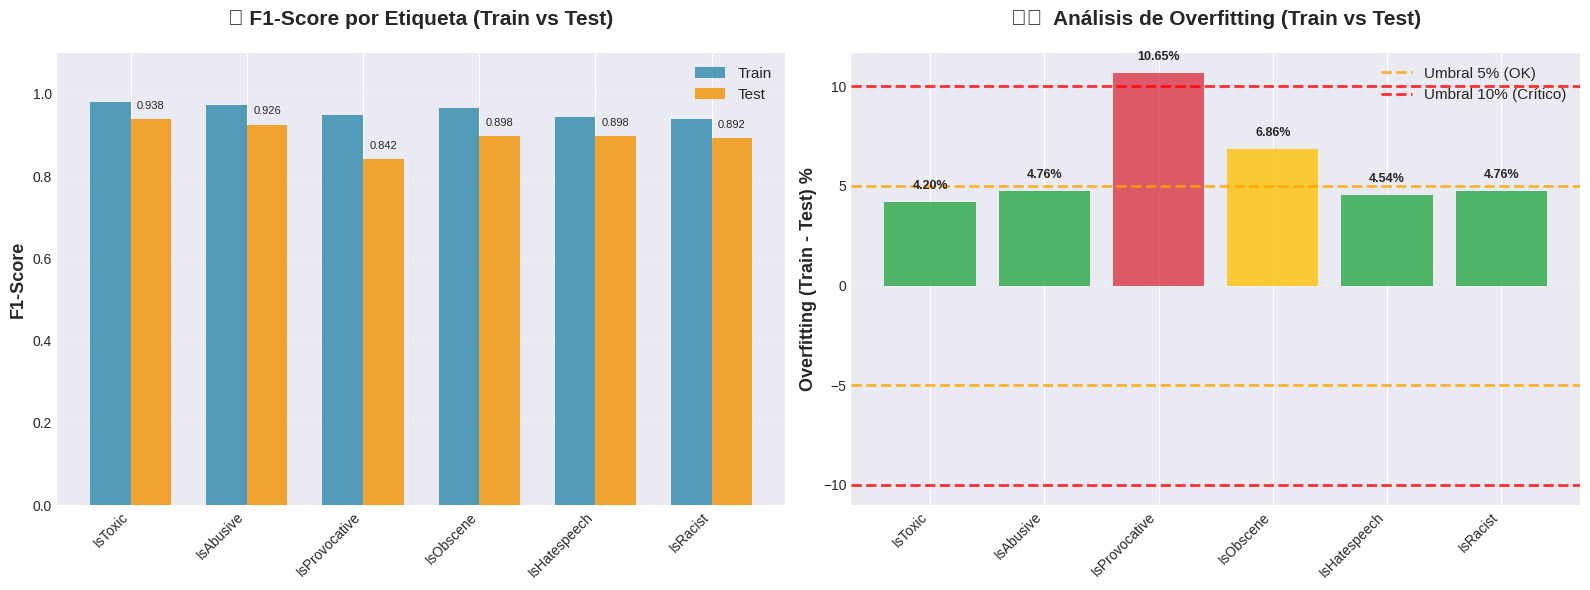

In [10]:
# Gráfico de comparación Train vs Test
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: F1-Score Train vs Test
x = np.arange(len(labels))
width = 0.35

bars1 = axes[0].bar(x - width/2, results_df['train_f1'], width, label='Train', alpha=0.8, color='#2E86AB')
bars2 = axes[0].bar(x + width/2, results_df['test_f1'], width, label='Test', alpha=0.8, color='#F18F01')

axes[0].set_ylabel('F1-Score', fontsize=13, fontweight='bold')
axes[0].set_title('📊 F1-Score por Etiqueta (Train vs Test)', fontsize=15, fontweight='bold', pad=20)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].set_ylim([0, 1.1])

# Añadir valores en las barras (solo para Test)
for bar in bars2:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Gráfico 2: Análisis de Overfitting
colors = ['#28a745' if abs(d) < 5 else '#ffc107' if abs(d) < 10 else '#dc3545' for d in results_df['overfitting_%']]
bars = axes[1].bar(labels, results_df['overfitting_%'], alpha=0.8, color=colors)

axes[1].axhline(y=5, color='orange', linestyle='--', linewidth=2, label='Umbral 5% (OK)', alpha=0.8)
axes[1].axhline(y=-5, color='orange', linestyle='--', linewidth=2, alpha=0.8)
axes[1].axhline(y=10, color='red', linestyle='--', linewidth=2, label='Umbral 10% (Crítico)', alpha=0.8)
axes[1].axhline(y=-10, color='red', linestyle='--', linewidth=2, alpha=0.8)
axes[1].set_ylabel('Overfitting (Train - Test) %', fontsize=13, fontweight='bold')
axes[1].set_title('⚠️  Análisis de Overfitting (Train vs Test)', fontsize=15, fontweight='bold', pad=20)
axes[1].set_xticklabels(labels, rotation=45, ha='right')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Añadir valores en las barras
for i, (bar, val) in enumerate(zip(bars, results_df['overfitting_%'])):
    y_pos = val + 0.5 if val > 0 else val - 0.5
    axes[1].text(bar.get_x() + bar.get_width()/2., y_pos,
                f'{val:.2f}%', ha='center', va='bottom' if val > 0 else 'top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Resumen Final

In [11]:
print("\n" + "="*100)
print(" "*30 + "📊 RESUMEN FINAL 📊")
print("="*100)

print(f"\n📊 Dataset:")
print(f"   - Total de muestras: {len(df)}")
print(f"   - Entrenamiento: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"   - Prueba: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
print(f"   - Split: Train-Test (80%-20%)")

print(f"\n🔧 Configuración del Modelo:")
print(f"   - Algoritmo: Support Vector Machine (LinearSVC)")
print(f"   - Estrategia: OneVsRestClassifier (Multi-Etiqueta)")
print(f"   - Vectorización: TF-IDF (max_features={tfidf.max_features})")
print(f"   - Regularización C: {svm_multilabel.estimator.C}")
print(f"   - class_weight: balanced")

avg_train_f1 = results_df['train_f1'].mean()
avg_test_f1 = results_df['test_f1'].mean()
avg_overfitting = (avg_train_f1 - avg_test_f1) * 100

print(f"\n🎯 Resultados:")
print(f"   - F1-Score Promedio Train: {avg_train_f1:.4f}")
print(f"   - F1-Score Promedio Test:  {avg_test_f1:.4f} ⭐")
print(f"   - Overfitting Promedio:    {avg_overfitting:.2f}%")

print(f"\n⚠️  Análisis de Overfitting:")
max_overfitting = results_df['overfitting_%'].abs().max()
if max_overfitting < 5:
    print(f"   ✅ EXCELENTE - NO hay overfitting ({max_overfitting:.2f}%)")
elif max_overfitting < 10:
    print(f"   ⚠️  ACEPTABLE - Overfitting leve ({max_overfitting:.2f}%)")
else:
    print(f"   ❌ CRÍTICO - Overfitting significativo ({max_overfitting:.2f}%)")

print("\n" + "="*100)
print("✅ Análisis Train-Test (80-20) completado")
print("="*100)


                              📊 RESUMEN FINAL 📊

📊 Dataset:
   - Total de muestras: 3749
   - Entrenamiento: 2999 (80.0%)
   - Prueba: 750 (20.0%)
   - Split: Train-Test (80%-20%)

🔧 Configuración del Modelo:
   - Algoritmo: Support Vector Machine (LinearSVC)
   - Estrategia: OneVsRestClassifier (Multi-Etiqueta)
   - Vectorización: TF-IDF (max_features=5000)
   - Regularización C: 0.1
   - class_weight: balanced

🎯 Resultados:
   - F1-Score Promedio Train: 0.9585
   - F1-Score Promedio Test:  0.8989 ⭐
   - Overfitting Promedio:    5.96%

⚠️  Análisis de Overfitting:
   ❌ CRÍTICO - Overfitting significativo (10.65%)

✅ Análisis Train-Test (80-20) completado


## 11. Guardar Modelo

In [ ]:
import joblib
import os

# Crear directorio para guardar modelos si no existe
model_dir = '../resources/models/'
os.makedirs(model_dir, exist_ok=True)

# Guardar el modelo SVM multi-etiqueta
model_path = os.path.join(model_dir, 'svm_multilabel_model_simple.pkl')
joblib.dump(svm_multilabel, model_path)
print(f"✓ Modelo guardado en: {model_path}")

# Guardar el vectorizador TF-IDF (para uso del backend SVM)
vectorizer_path = os.path.join(model_dir, 'tfidf_vectorizer_svm.pkl')
joblib.dump(tfidf, vectorizer_path)
print(f"✓ Vectorizador guardado en: {vectorizer_path}")


# Guardar métricas del modelo para referencia
metrics_path = os.path.join(model_dir, 'model_metrics_simple.csv')
results_df.to_csv(metrics_path, index=False)
print(f"✓ Métricas guardadas en: {metrics_path}")

print("\n" + "="*80)
print("🎉 MODELO GUARDADO EXITOSAMENTE")
print("="*80)


✓ Modelo guardado en: ../resources/models/svm_multilabel_model_simple.pkl
✓ Vectorizador guardado en: ../resources/models/tfidf_vectorizer_svm.pkl
✓ Vectorizador guardado (copia) en: ../resources/models/tfidf_vectorizer_simple.pkl
✓ Métricas guardadas en: ../resources/models/model_metrics_simple.csv

🎉 MODELO GUARDADO EXITOSAMENTE
